# **1. Perkenalan Dataset**


## Dataset: Wine Quality (UCI Machine Learning Repository)

Dataset ini berisi informasi tentang kualitas wine merah dan putih dari Portugal.
Dataset diperoleh dari UCI ML Repository: https://archive.ics.uci.edu/ml/datasets/wine+quality

**Informasi Dataset:**
- **Jumlah sampel**: ~6497 baris (red + white wine)
- **Jumlah fitur**: 12 kolom (11 fitur input + 1 target)
- **Task**: Binary Classification — wine berkualitas baik (quality >= 6) atau buruk (quality < 6)
- **Fitur input**: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol
- **Target**: quality (binary: 0 = bad, 1 = good)

**Alasan pemilihan dataset:**
1. Dataset publik yang tersedia di UCI ML Repository (reliable)
2. Cocok untuk binary classification
3. Memiliki banyak fitur numerik sehingga preprocessing kaya
4. Ukuran ideal untuk eksperimen MLOps


# **2. Import Library**

Mengimpor seluruh library Python yang dibutuhkan untuk analisis data, preprocessing, dan visualisasi.

In [1]:
# ── Data Manipulation ──
import pandas as pd
import numpy as np

# ── Visualisasi ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ──
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── Utility ──
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print('✅ Semua library berhasil diimport')
print(f'pandas version: {pd.__version__}')
print(f'numpy version: {np.__version__}')

✅ Semua library berhasil diimport
pandas version: 2.2.3
numpy version: 1.26.4


# **3. Memuat Dataset**

Memuat dataset Wine Quality dari UCI ML Repository menggunakan URL langsung.

In [2]:
# ── Download dataset dari UCI ML Repository ──
url_red = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

# Tambahkan kolom tipe wine
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Gabungkan dataset
df = pd.concat([df_red, df_white], ignore_index=True)

# Simpan raw dataset
os.makedirs('../winequality_raw', exist_ok=True)
df.to_csv('../winequality_raw/winequality_raw.csv', index=False)

print(f'✅ Dataset berhasil dimuat')
print(f'Total baris: {df.shape[0]}')
print(f'Total kolom: {df.shape[1]}')
print(f'\nBeberapa baris pertama:')
df.head()

✅ Dataset berhasil dimuat
Total baris: 6497
Total kolom: 13

Beberapa baris pertama:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
# ── Informasi dasar dataset ──
print('=== INFO DATASET ===')
print(df.info())
print('\n=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None

=== STATISTIK DESKRIPTIF ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# **4. Exploratory Data Analysis (EDA)**

Melakukan analisis eksplorasi data untuk memahami karakteristik dataset secara mendalam.

=== DISTRIBUSI QUALITY ===
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


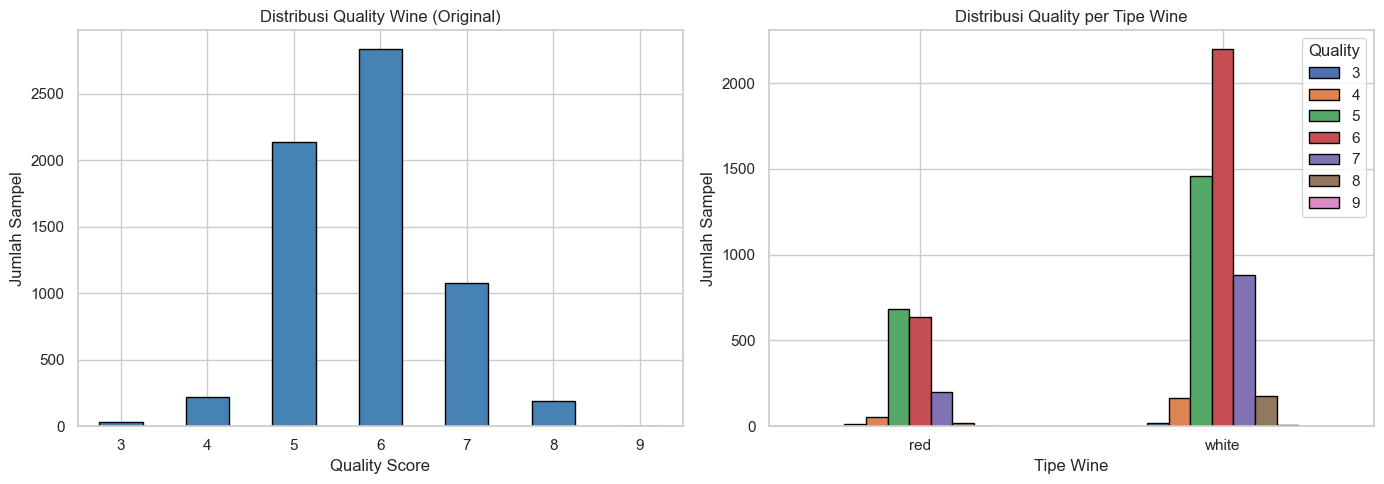

✅ Plot distribusi quality disimpan


In [4]:
# ── 4.1 Distribusi Target (Quality) ──
print('=== DISTRIBUSI QUALITY ===')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi quality original
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Quality Wine (Original)')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(rotation=0)

# Distribusi per wine type
df.groupby(['wine_type', 'quality']).size().unstack().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Distribusi Quality per Tipe Wine')
axes[1].set_xlabel('Tipe Wine')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].tick_params(rotation=0)
axes[1].legend(title='Quality', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('eda_quality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot distribusi quality disimpan')

In [5]:
# ── 4.2 Cek Missing Values ──
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print('✅ Tidak ada missing values')
else:
    print(f'⚠️  Total missing values: {missing.sum()}')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✅ Tidak ada missing values


In [6]:
# ── 4.3 Cek Duplikasi ──
print('=== DUPLIKASI DATA ===')
duplicate_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicate_count}')
print(f'Persentase duplikat: {duplicate_count/len(df)*100:.2f}%')

=== DUPLIKASI DATA ===
Jumlah baris duplikat: 1177
Persentase duplikat: 18.12%


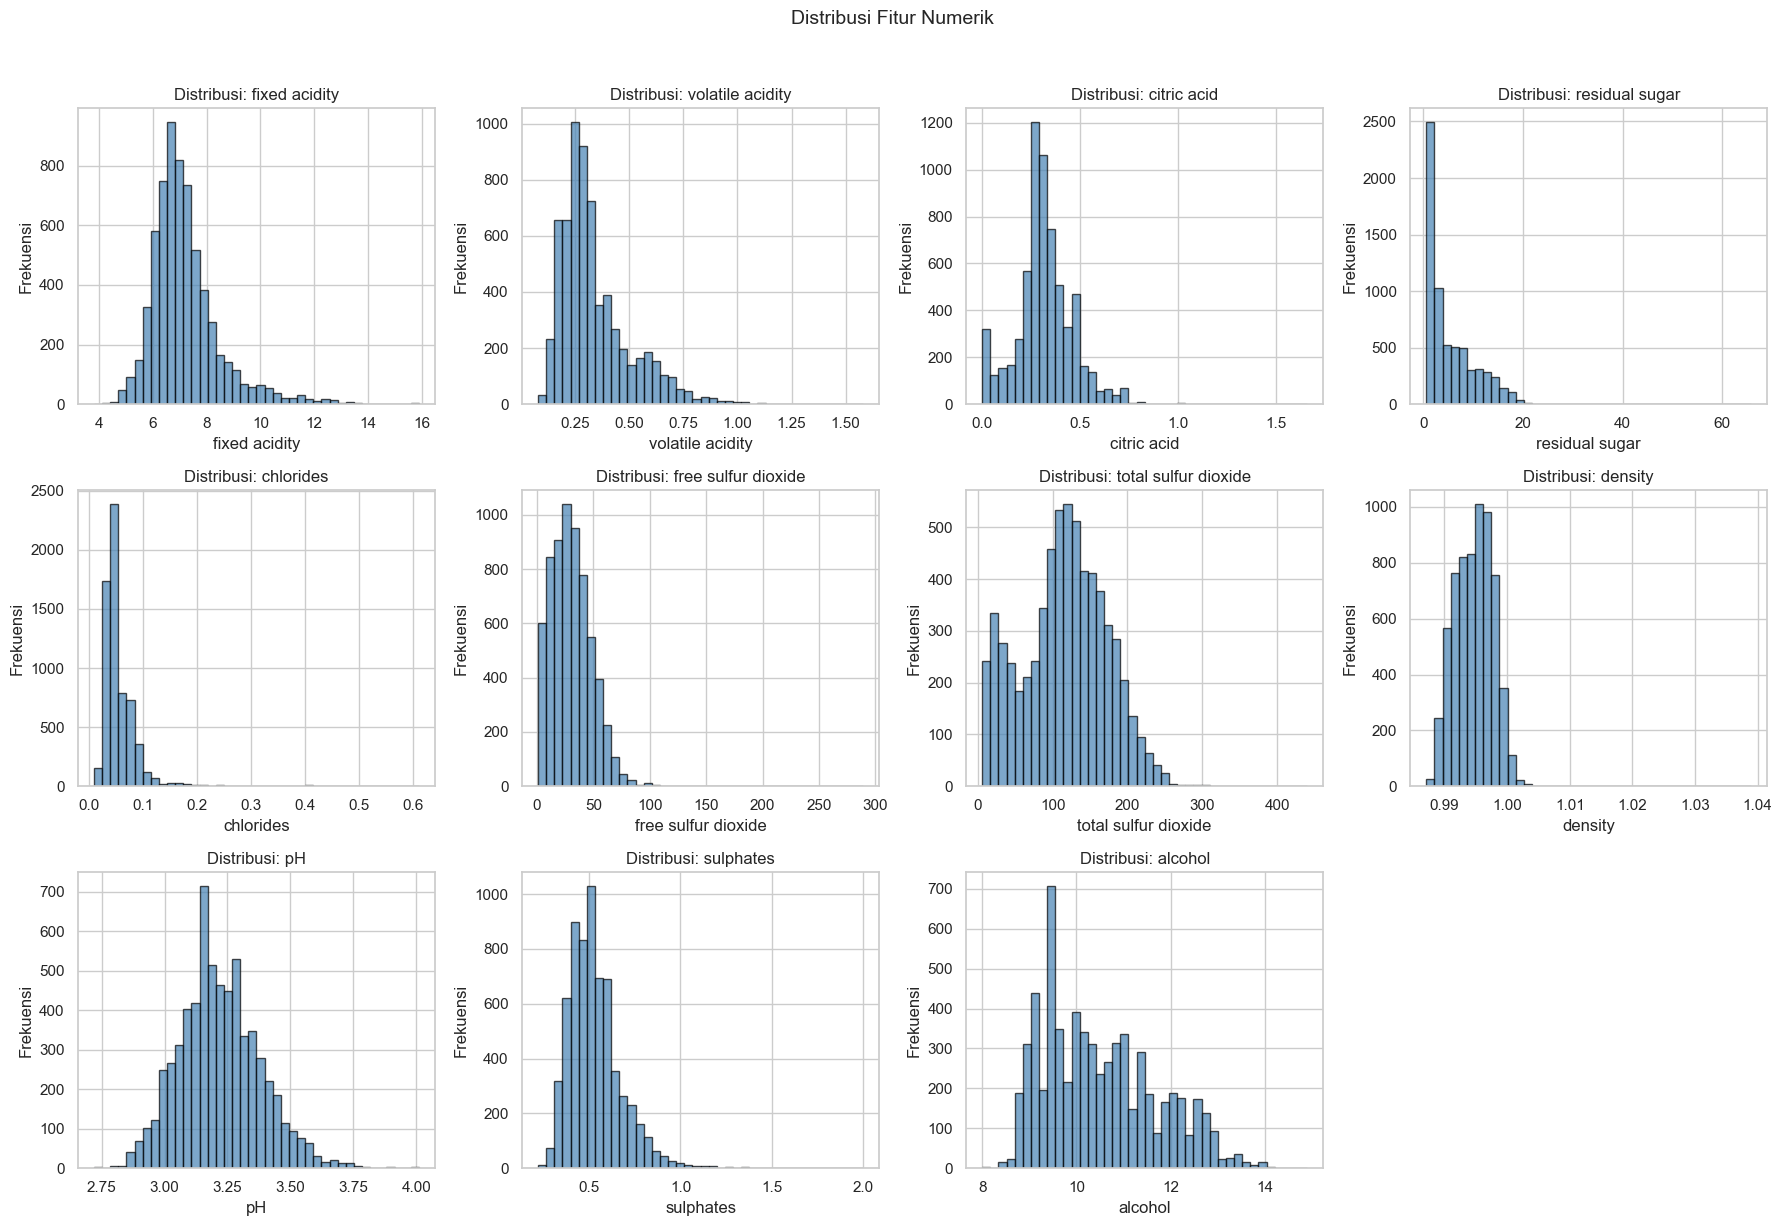

✅ Plot distribusi fitur disimpan


In [7]:
# ── 4.4 Distribusi Fitur Numerik ──
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan subplot kosong
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot distribusi fitur disimpan')

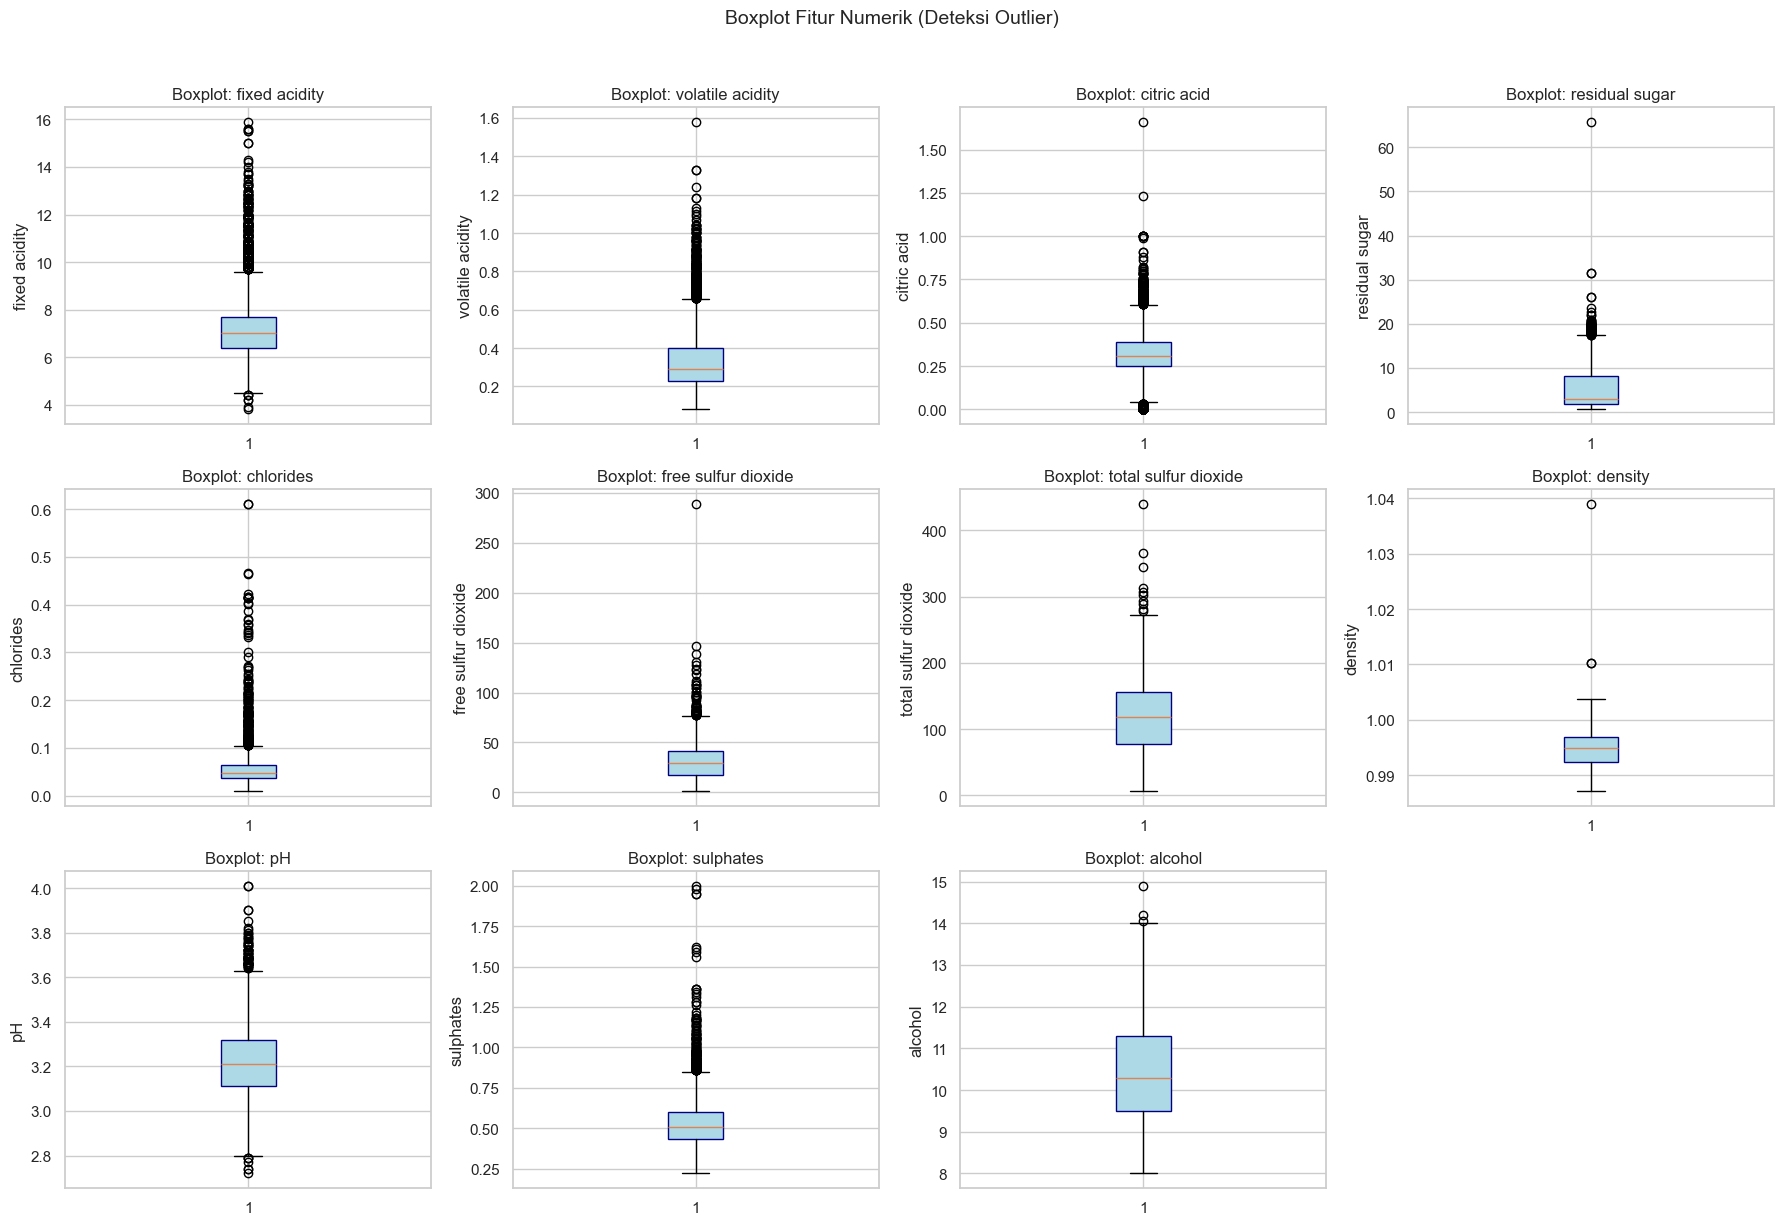

✅ Boxplot disimpan


In [8]:
# ── 4.5 Boxplot untuk Deteksi Outlier ──
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'))
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Boxplot disimpan')

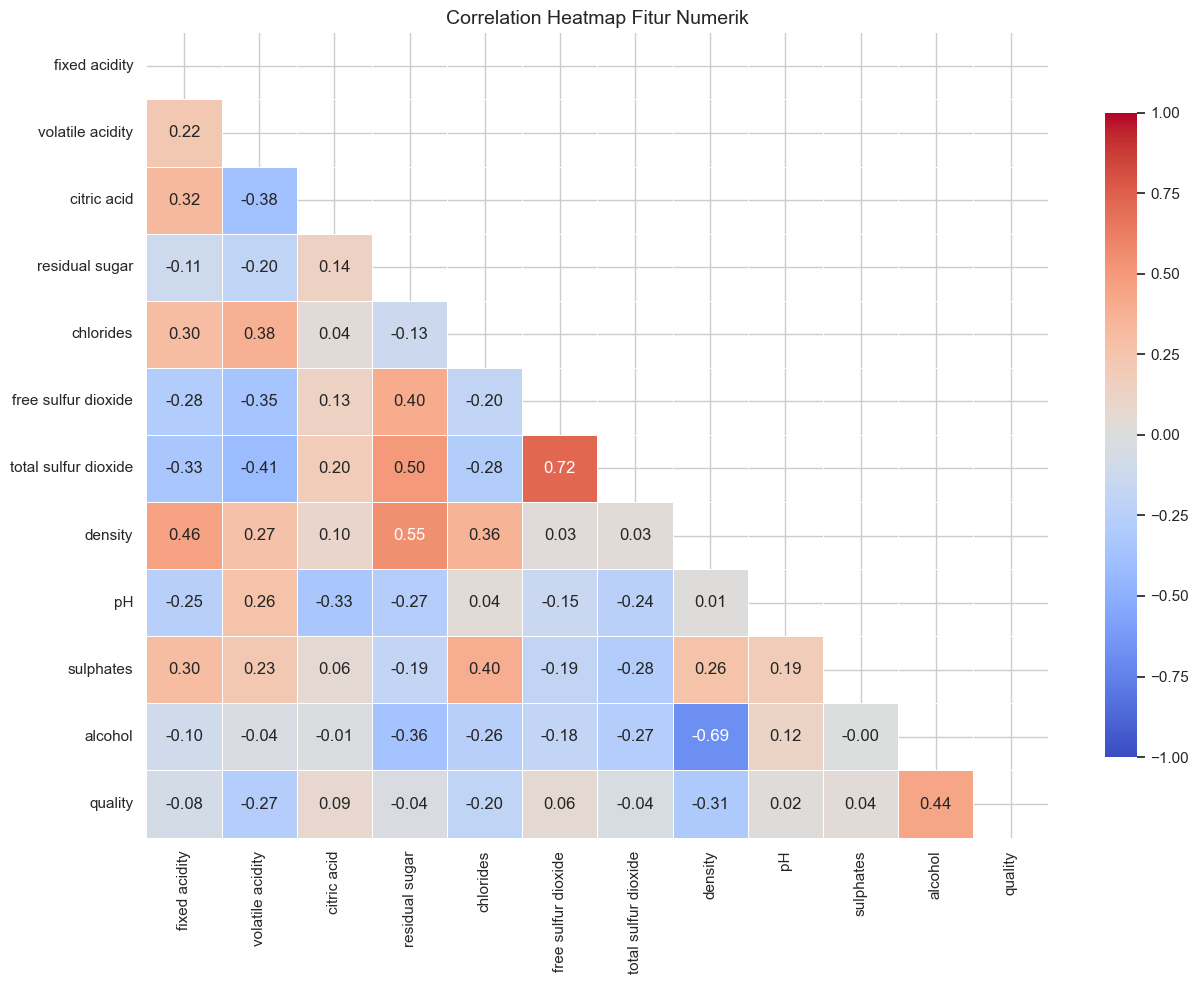

✅ Heatmap korelasi disimpan


In [9]:
# ── 4.6 Correlation Heatmap ──
plt.figure(figsize=(13, 10))
corr_matrix = df[numerical_cols + ['quality']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap korelasi disimpan')

=== KORELASI FITUR DENGAN QUALITY ===
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


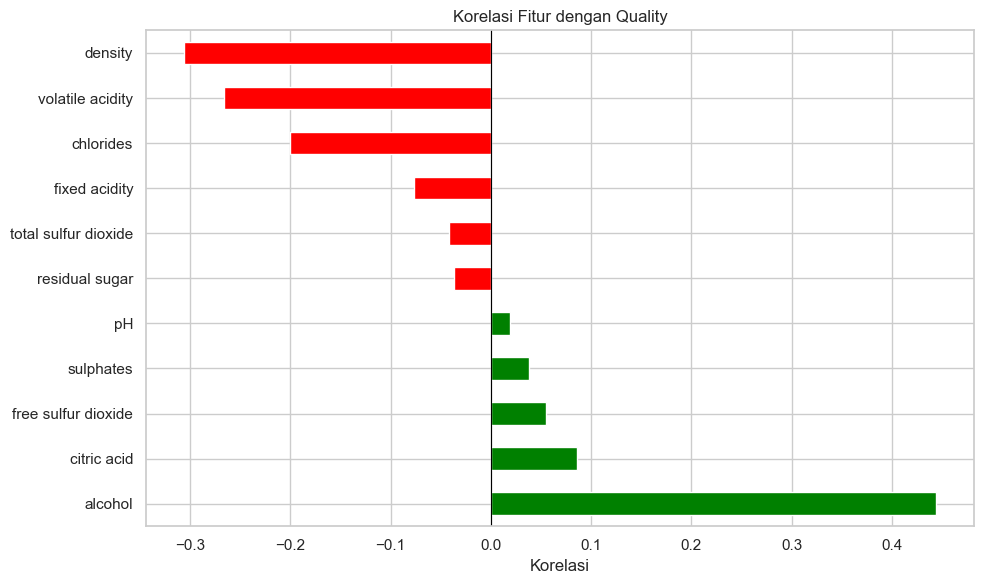

✅ Plot korelasi target disimpan


In [10]:
# ── 4.7 Analisis korelasi dengan target ──
print('=== KORELASI FITUR DENGAN QUALITY ===')
corr_with_target = df[numerical_cols + ['quality']].corr()['quality'].drop('quality').sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(10, 6))
corr_with_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_with_target])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur dengan Quality')
plt.xlabel('Korelasi')
plt.tight_layout()
plt.savefig('eda_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot korelasi target disimpan')

# **5. Data Preprocessing**

Melakukan preprocessing data secara lengkap:
1. Membuat label biner dari kolom quality
2. Menghapus duplikasi
3. Handling missing values
4. Deteksi dan penanganan outlier (IQR method)
5. Encoding fitur kategorikal
6. Normalisasi/Standarisasi fitur numerik
7. Split data train/test

In [11]:
# ── 5.1 Buat target biner ──
# quality >= 6 → good (1), quality < 6 → bad (0)
df['quality_label'] = (df['quality'] >= 6).astype(int)

print('=== DISTRIBUSI TARGET BINER ===')
print(df['quality_label'].value_counts())
print(f"\nPersentase: {df['quality_label'].value_counts(normalize=True).round(3) * 100}")

=== DISTRIBUSI TARGET BINER ===
quality_label
1    4113
0    2384
Name: count, dtype: int64

Persentase: quality_label
1    63.3
0    36.7
Name: proportion, dtype: float64


In [12]:
# ── 5.2 Hapus duplikasi ──
df_clean = df.copy()
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'✅ Duplikasi dihapus: {before - after} baris')
print(f'Sisa data: {after} baris')

✅ Duplikasi dihapus: 1177 baris
Sisa data: 5320 baris


In [13]:
# ── 5.3 Handle missing values ──
# Isi missing values numerik dengan median
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'Kolom {col}: diisi dengan median = {median_val:.4f}')

print(f'✅ Missing values setelah handling: {df_clean.isnull().sum().sum()}')

✅ Missing values setelah handling: 0


In [14]:
# ── 5.4 Handling Outlier dengan IQR ──
def remove_outliers_iqr(df, cols, multiplier=1.5):
    """Hapus outlier menggunakan metode IQR."""
    df_out = df.copy()
    total_removed = 0
    for col in cols:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before = len(df_out)
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
        removed = before - len(df_out)
        if removed > 0:
            print(f'  {col}: {removed} outlier dihapus (range: {lower:.4f} - {upper:.4f})')
        total_removed += removed
    return df_out, total_removed

print('=== HANDLING OUTLIER (IQR) ===')
before_outlier = len(df_clean)
df_clean, total_removed = remove_outliers_iqr(df_clean, numerical_cols)
print(f'\nTotal outlier dihapus: {total_removed}')
print(f'Sisa data: {len(df_clean)} baris ({len(df_clean)/before_outlier*100:.1f}%)')

=== HANDLING OUTLIER (IQR) ===
  fixed acidity: 304 outlier dihapus (range: 4.4500 - 9.6500)
  volatile acidity: 310 outlier dihapus (range: -0.0250 - 0.6550)
  citric acid: 322 outlier dihapus (range: 0.0550 - 0.5750)
  residual sugar: 85 outlier dihapus (range: -7.6000 - 17.2000)
  chlorides: 325 outlier dihapus (range: 0.0075 - 0.0835)
  free sulfur dioxide: 43 outlier dihapus (range: -14.5000 - 77.5000)
  total sulfur dioxide: 8 outlier dihapus (range: 3.0000 - 251.0000)
  pH: 31 outlier dihapus (range: 2.7950 - 3.6350)
  sulphates: 80 outlier dihapus (range: 0.1800 - 0.8200)

Total outlier dihapus: 1508
Sisa data: 3812 baris (71.7%)


In [15]:
# ── 5.5 Encoding fitur kategorikal ──
# Encode wine_type: red=0, white=1
le = LabelEncoder()
df_clean['wine_type_encoded'] = le.fit_transform(df_clean['wine_type'])
print('=== ENCODING wine_type ===')
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(f'✅ Encoding selesai')

=== ENCODING wine_type ===
{'red': 0, 'white': 1}
✅ Encoding selesai


In [16]:
# ── 5.6 Standarisasi fitur numerik ──
feature_cols = numerical_cols + ['wine_type_encoded']
target_col = 'quality_label'

X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print('=== STANDARISASI FITUR ===')
print(f'Mean sebelum scaling: {X[numerical_cols[:3]].mean().round(4).to_dict()}')
print(f'Mean setelah scaling: {X_scaled_df[numerical_cols[:3]].mean().round(4).to_dict()}')
print(f'Std setelah scaling: {X_scaled_df[numerical_cols[:3]].std().round(4).to_dict()}')
print(f'✅ Standarisasi selesai')

=== STANDARISASI FITUR ===
Mean sebelum scaling: {'fixed acidity': 6.9077, 'volatile acidity': 0.291, 'citric acid': 0.3181}
Mean setelah scaling: {'fixed acidity': 0.0, 'volatile acidity': -0.0, 'citric acid': -0.0}
Std setelah scaling: {'fixed acidity': 1.0001, 'volatile acidity': 1.0001, 'citric acid': 1.0001}
✅ Standarisasi selesai


In [17]:
# ── 5.7 Train-Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print('=== TRAIN-TEST SPLIT ===')
print(f'Total data: {len(X_scaled_df)}')
print(f'Train: {len(X_train)} ({len(X_train)/len(X_scaled_df)*100:.1f}%)')
print(f'Test: {len(X_test)} ({len(X_test)/len(X_scaled_df)*100:.1f}%)')
print(f'\nDistribusi target (train): {y_train.value_counts().to_dict()}')
print(f'Distribusi target (test): {y_test.value_counts().to_dict()}')

=== TRAIN-TEST SPLIT ===
Total data: 3812
Train: 3049 (80.0%)
Test: 763 (20.0%)

Distribusi target (train): {1: 2064, 0: 985}
Distribusi target (test): {1: 516, 0: 247}


In [18]:
# ── 5.8 Simpan dataset yang sudah dipreprocess ──
os.makedirs('winequality_preprocessing', exist_ok=True)

# Gabungkan fitur dan target
train_df = pd.concat([X_train.reset_index(drop=True),
                      y_train.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test.reset_index(drop=True),
                      y_test.reset_index(drop=True)], axis=1)

train_df.to_csv('winequality_preprocessing/winequality_train.csv', index=False)
test_df.to_csv('winequality_preprocessing/winequality_test.csv', index=False)

# Simpan juga dataset lengkap yang sudah bersih
final_df = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)
final_df.to_csv('winequality_preprocessing/winequality_clean.csv', index=False)

print('✅ Dataset preprocessing berhasil disimpan:')
print(f'  - winequality_preprocessing/winequality_train.csv ({len(train_df)} baris)')
print(f'  - winequality_preprocessing/winequality_test.csv ({len(test_df)} baris)')
print(f'  - winequality_preprocessing/winequality_clean.csv ({len(final_df)} baris)')
print(f'\n✅ EKSPERIMEN SELESAI — Dataset siap untuk tahap modeling!')

✅ Dataset preprocessing berhasil disimpan:
  - winequality_preprocessing/winequality_train.csv (3049 baris)
  - winequality_preprocessing/winequality_test.csv (763 baris)
  - winequality_preprocessing/winequality_clean.csv (3812 baris)

✅ EKSPERIMEN SELESAI — Dataset siap untuk tahap modeling!
